<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/fusemachines-2026/phase3/NEU_Surface_Defect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement 
You are a junior ML engineer at
SmartForge Manufacturing. The production line images thousands of steel strips
every day. Manual visual inspection is slow, inconsistent, and misses subtle
defects that cause costly downstream failures. The engineering team needs two
things:
1. a model that can identify which type of defect is present, and 
2. evidence that the model is robust enough to handle real production variability
(different lighting, orientations, and surface conditions). Your job is to
build and harden that model using PyTorch.

### Setup 

In [61]:
# imports
import torch 
import torch.nn as nn 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
tfm = transforms.Compose([
    transforms.Resize((200,200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])
train_ds = datasets.ImageFolder('NEU-DET/train/images',transform=tfm)
test_ds = datasets.ImageFolder('NEU-DET/validation/images',transform=tfm)


In [4]:
print("Number of images:", len(train_ds))
print("Classes:", train_ds.classes)
print("Class to index:", train_ds.class_to_idx)

Number of images: 1440
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class to index: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [5]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

In [6]:
train_loader

# Part 0 : NN Foundations 

### 1. Implement a simple 2-layer neural network from scratch
using nn.Module no nn.Sequential shortcuts. Define __init__ and forward
explicitly.


Build: 

1. `__init__ `: explicitly defines layers as attribute 
2. `x.view(x.size(0), -1)` inside forward  since images come in as (batch_size, 3, 200, 200) from the DataLoader, and a Linear layer expects a flat 2D input (batch_size, features),flatten every dimension except the batch dimension. 

3. No activation after fc2 the raw logits are returned directly, because nn.CrossEntropyLoss expects raw logits and applies log_softmax internally. Adding a Softmax here yourself would double-apply it and break training.

In [7]:
class Simple2LayerNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size ):
        super().__init__()

        #layer 1 
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, X):
        X = X.view(X.size(0), -1) 
        X = self.fc1(X)
        X = self.relu(X)
        X = self.fc2(X)
        return X


##### Build
1. `__init__` explicitly defines layers ass attributes

2. x.view(x.size(0),-1 ) the image comes in ass (batch_ize, 3, 200,200), from the dataloader and a linear layer expects a flat 2D input `(batch_size, features)`

3. No activattion after `fc2`: the raw logits are retrned directky, becase nn.CrossEntropy loss expects rawlogits, and applies softmax internally 

### 2. Activation functions: swap ReLU for Sigmoid in your hidden layer and compare convergence over 20 epochs. What do you notice?

In [37]:
class Simple2LayerNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, activation = "relu"):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU() if activation == "relu" else nn.Sigmoid()  # to decrease redundanct code
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1) #compress to 2d
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x 

In [52]:
def train_model(model, optimizer, train_loader, criterion, epochs=20):
    loss_hist = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for image, label in train_loader:
            output = model(image)
            loss = criterion(output, label)
            optimizer.zero_grad() # clears the gradients from the previous step ;pt accumulates grad by efault
            loss.backward() #backpropagation
            optimizer.step() #upates the model weights 
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_hist.append(avg_loss)
        print(f"Epochs {epoch+1}/ {epochs}, Loss : {avg_loss}")
    return loss_hist

In [56]:
# model parameters 
input_size = 3 * 200 * 200
# 3 for color RGB and 200x200 is image hxw
hidden_size = 128 
num_classes = len(train_ds.classes)
criterion = nn.CrossEntropyLoss()
epochs = 20 

In [57]:
# for reprodiuciblity ; why always 42--Not always 42; justa  lucky number; can use any number 
torch.manual_seed(42 )
# for relu 
model_relu = Simple2LayerNN(input_size, hidden_size, num_classes, activation = "relu")

In [58]:
#reset seed to the same vlaue so model_sigmoid gets identical initital weights 
torch.manual_seed(42)
model_sigmoid = Simple2LayerNN(input_size, hidden_size, num_classes, activation = "sigmoid")

In [59]:
# seperate optimizer for each model, adam tracks per-parameter state, so eacch model needs its own instance 
opt_relu = torch.optim.Adam(model_relu.parameters(), lr=0.001)
opt_sigmoid = torch.optim.Adam(model_sigmoid.parameters(), lr=0.001)


In [60]:
print("Training with ReLU.......")
loss_relu = train_model(model_relu, opt_relu, train_loader, criterion, epochs)


Training with ReLU.......
Epochs 1/ 20, Loss : 14.745438967810736
Epochs 2/ 20, Loss : 8.657253779305352
Epochs 3/ 20, Loss : 6.463003412882487
Epochs 4/ 20, Loss : 5.278574249479505
Epochs 5/ 20, Loss : 3.042806702189975
Epochs 6/ 20, Loss : 2.956722068786621
Epochs 7/ 20, Loss : 3.8283591588338215
Epochs 8/ 20, Loss : 4.0359620852602855
Epochs 9/ 20, Loss : 2.1650445030795202
Epochs 10/ 20, Loss : 1.726602178812027
Epochs 11/ 20, Loss : 1.5394811507728365
Epochs 12/ 20, Loss : 1.5329998119009867
Epochs 13/ 20, Loss : 1.2566487060652838
Epochs 14/ 20, Loss : 2.36754211584727
Epochs 15/ 20, Loss : 1.3318881195452479
Epochs 16/ 20, Loss : 0.8513764441013336
Epochs 17/ 20, Loss : 0.8888723303874334
Epochs 18/ 20, Loss : 1.1629293660322826
Epochs 19/ 20, Loss : 1.1246533311075635
Epochs 20/ 20, Loss : 0.8246496273411645


In [63]:
print("Training with sigmoid........")
loss_sigmoid = train_model(model_sigmoid, opt_sigmoid, train_loader, criterion, epochs)

Training with sigmoid........
Epochs 1/ 20, Loss : 1.6509633170233833
Epochs 2/ 20, Loss : 1.5487802240583632
Epochs 3/ 20, Loss : 1.5068914863798353
Epochs 4/ 20, Loss : 1.4785277605056764
Epochs 5/ 20, Loss : 1.4741892947090998
Epochs 6/ 20, Loss : 1.4461919811036852
Epochs 7/ 20, Loss : 1.4169582658343844
Epochs 8/ 20, Loss : 1.4069631576538086
Epochs 9/ 20, Loss : 1.3878456777996486
Epochs 10/ 20, Loss : 1.3770901891920302
Epochs 11/ 20, Loss : 1.3592094315422907
Epochs 12/ 20, Loss : 1.3546625667148167
Epochs 13/ 20, Loss : 1.3387040535608927
Epochs 14/ 20, Loss : 1.3158487108018664
Epochs 15/ 20, Loss : 1.304413980907864
Epochs 16/ 20, Loss : 1.2901036977767943
Epochs 17/ 20, Loss : 1.2918552902009752
Epochs 18/ 20, Loss : 1.2972790718078613
Epochs 19/ 20, Loss : 1.2890637556711833
Epochs 20/ 20, Loss : 1.2961081796222262


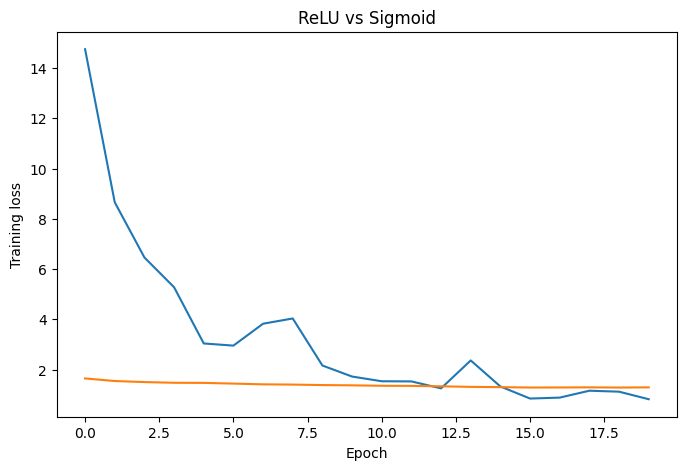

In [65]:
plt.figure(figsize=(8,5))
plt.plot(loss_relu, label="ReLU")
plt.plot(loss_sigmoid, label= "sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("ReLU vs Sigmoid")
plt.show()

### Observations
ReLU converged faster and reach a lower loss within 20 epochs 
Sigmoid converged more lowly, and the loss curve look almost flat and at last it dropped littlebit 

whay did it happened 
1. vanishing gradients : sigmoid squashes any intput to `(0,1)`. Its derivative hass a max value of only 0.25(at x =0), and get close to 0 when the input is large 